In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


=== TASK 2: UNEMPLOYMENT DATA PROFILING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB
None


/tmp/ipykernel_58/985963730.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', style='Area', markers=True, ci=None)


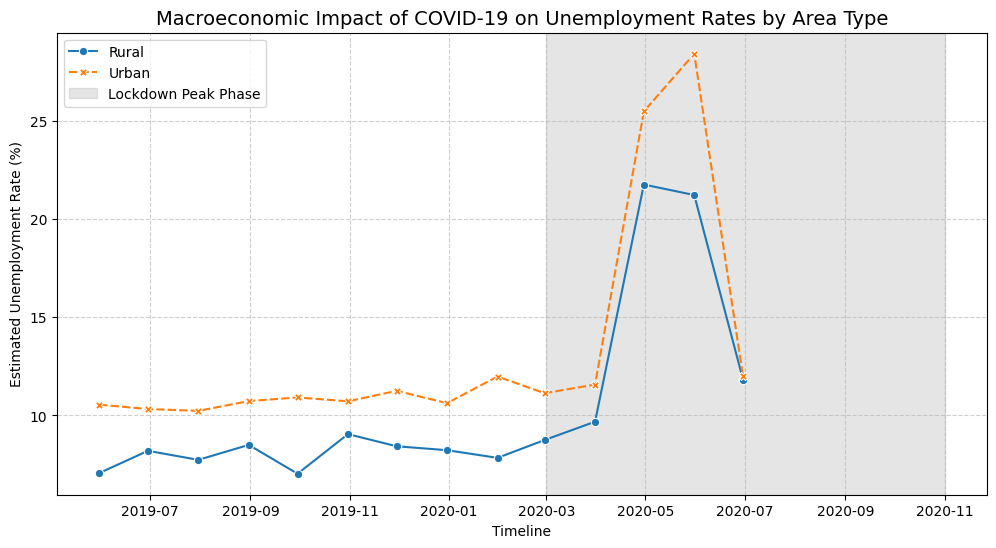

/tmp/ipykernel_58/985963730.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_unemp.head(10), x='Estimated Unemployment Rate (%)', y='Region', palette='rocket')


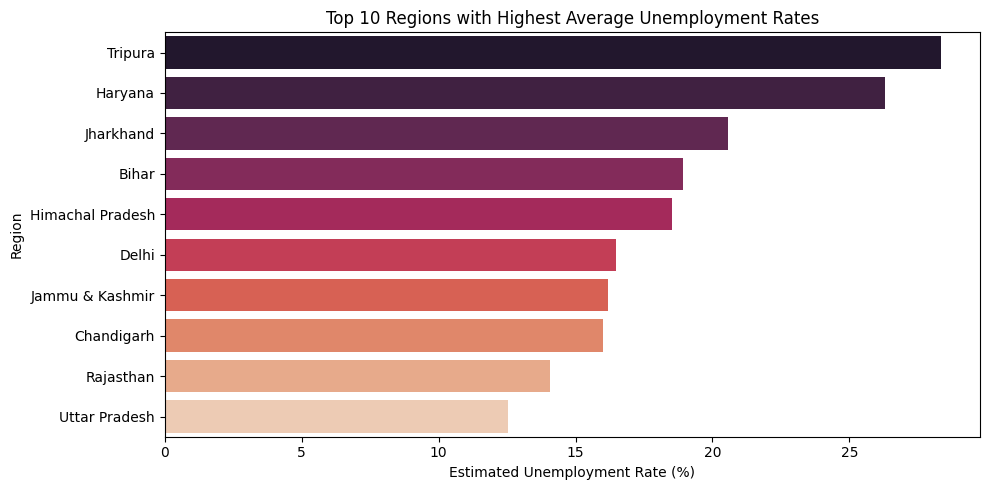

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean Data
# Replace 'Unemployment_in_India.csv' with your exact file name
df = pd.read_csv('/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv')

# Clean column spaces (Kaggle datasets often have hidden spaces in headers)
df.columns = df.columns.str.strip()

# Convert date column to datetime object securely
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

print("=== TASK 2: UNEMPLOYMENT DATA PROFILING ===")
print(df.info())

# 2. Advanced Aggregation: Regional Analysis
regional_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()

# 3. Visualizing Covid-19 Shockwave Analytics
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', style='Area', markers=True, ci=None)
plt.axvspan('2020-03-01', '2020-11-01', color='grey', alpha=0.2, label='Lockdown Peak Phase')
plt.title("Macroeconomic Impact of COVID-19 on Unemployment Rates by Area Type", fontsize=14)
plt.xlabel("Timeline")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("unemployment_covid_impact.png")
plt.show()

# Top 10 worst affected regions plot
plt.figure(figsize=(10, 5))
sns.barplot(data=regional_unemp.head(10), x='Estimated Unemployment Rate (%)', y='Region', palette='rocket')
plt.title("Top 10 Regions with Highest Average Unemployment Rates")
plt.tight_layout()
plt.savefig("unemployment_regional_impact.png")
plt.show()